<a href="https://colab.research.google.com/github/m-nurbek/diff-rss/blob/main/model_evaluation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade sympy

In [2]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 11.4 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import griddata
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
print(np.__version__)
print(pd.__version__)

2.0.2
2.2.2


In [4]:
ap_mean_by_xy_KNN = pd.read_csv("./ap_mean_imputed_KNN.csv")
ap_median_by_xy_KNN = pd.read_csv("./ap_median_imputed_KNN.csv")
ap_mean_by_xy_IDW = pd.read_csv('./ap_mean_by_xy_imputed_IDW.csv')
ap_median_by_xy_IDW = pd.read_csv('./ap_median_by_xy_imputed_IDW.csv')

In [5]:
def plot_RF(floor_df, label):
    fig, ax = plt.subplots()
    ax.scatter(floor_df['X'], floor_df['Y'])
    ax.set_xlabel('X(m)')
    ax.set_ylabel('Y(m)')
    ax.set_title(label)
    plt.show()

In [6]:
# Feature Columns
def get_ap_columns(dataset):
    return [col for col in dataset.columns if col.startswith('AP')]

In [7]:
def plot_indoor_localization_results(true_locations, predicted_locations, title):
    # Plotting
    plt.figure(figsize=(8, 6))

    # Scatter plots for the points
    plt.scatter(true_locations[:, 0], true_locations[:, 1], c='yellow', marker='x', s=100, label="True locations")
    plt.scatter(predicted_locations[:, 0], predicted_locations[:, 1], c='r', alpha=0.5, label="KNN (model trained data)")


    # Draw lines connecting the true points with synthetic predictions
    for i in range(len(true_locations)):
        plt.plot([true_locations[i, 0], predicted_locations[i, 0]],
                [true_locations[i, 1], predicted_locations[i, 1]],
                c='red', linestyle=':', linewidth=1)  # Lines between true and synthetic

    # Labels and title
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()

    # Show the plot
    plt.show()

In [8]:
def subsample_every_n(df, N, origin=(None,None), tol=1e-8):
    """
    Split df into two parts:
      • df_kept: rows where (X−x0) and (Y−y0) are multiples of N
      • df_rest: all the other rows

    Parameters
    ----------
    df : DataFrame with columns 'X','Y'
    N  : float           the grid spacing you want (e.g. 5.0)
    origin : (x0,y0)     the “zero” of your grid; if None, uses (min X, min Y)
    tol : float          tolerance for floating-point modulo

    Returns
    -------
    df_kept, df_rest : DataFrames
    """
    df2 = df.copy()

    # 1) determine grid origin
    x0 = origin[0] if origin[0] is not None else df2['X'].min()
    y0 = origin[1] if origin[1] is not None else df2['Y'].min()

    # 2) compute offsets
    dx = df2['X'] - x0
    dy = df2['Y'] - y0

    # 3) boolean mask for “on-grid” points
    on_grid = (
        np.isclose(dx.mod(N), 0.0, atol=tol) &
        np.isclose(dy.mod(N), 0.0, atol=tol)
    )

    # 4) split
    df_kept = df2.loc[on_grid].reset_index(drop=True)
    df_rest = df2.loc[~on_grid].reset_index(drop=True)

    return df_kept, df_rest

In [9]:
# Define a function to compute the Euclidean distance error.
def compute_localization_errors(true_locations, predicted_locations):
    errors = np.sqrt(np.sum((true_locations - predicted_locations)**2, axis=1))
    return errors

In [10]:
def fraction(actual, orig):
    return actual.shape[0] / orig.shape[0] * 100

# KNN Model Evaluation

In [11]:
cond_cols = ['X','Y']

In [12]:
def knn_evaluation(X_train, X_test, y_train, y_test, plot_label="Localization errors"):
    knn_scaler=StandardScaler()
    X_ap_train_scaled = knn_scaler.fit_transform(X_train)

    # --- Custom Weight Function (1 / distance^2) ---
    def inverse_squared_weight(distances):
        # Avoid division by zero for exact matches
        # (replace 0 with a tiny number)
        distances = np.maximum(distances, 1e-10)
        return 1.0 / (distances ** 2)

    # KNN multi-output
    knn = KNeighborsRegressor(
        weights=inverse_squared_weight,
        metric='manhattan')

    param_grid = {'n_neighbors': range(3, 10)}
    grid_search = GridSearchCV(knn, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_search.fit(X_ap_train_scaled, y_train)
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best score: {grid_search.best_score_}")

    knn_best = grid_search.best_estimator_

    pred_locations_test = knn_best.predict(knn_scaler.transform(X_test))

    print(f"Localization Error: {np.mean(compute_localization_errors(y_test, pred_locations_test))}")

    plot_indoor_localization_results(y_test, pred_locations_test, plot_label)

In [13]:
def evaluate_knn(train_dataset, test_dataset, plot_label="Localization errors"):
    X_ap_train = train_dataset[get_ap_columns(train_dataset)].values
    y_xy_train = train_dataset[cond_cols].values

    X_ap_test = test_dataset[get_ap_columns(test_dataset)].values
    y_xy_test = test_dataset[cond_cols].values

    knn_evaluation(X_ap_train, X_ap_test, y_xy_train, y_xy_test, plot_label=plot_label)

### 100% of the dataset

Best parameters: {'n_neighbors': 3}
Best score: -3.779251392651481
Localization Error: 0.0


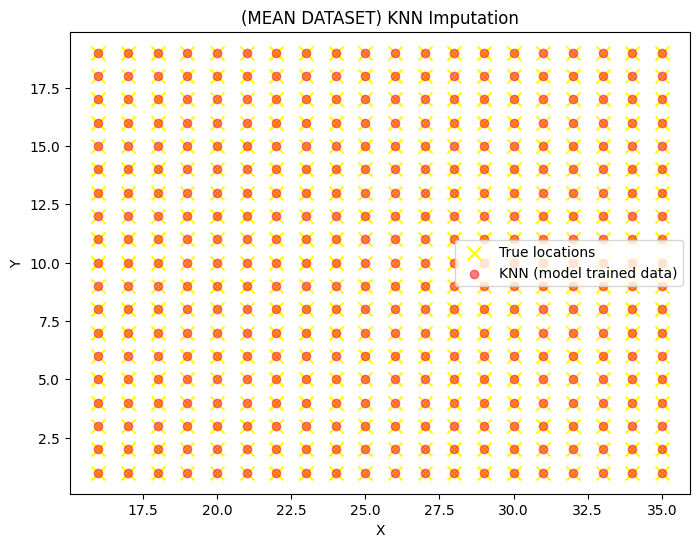

Best parameters: {'n_neighbors': 5}
Best score: -3.7080705038231456
Localization Error: 0.0


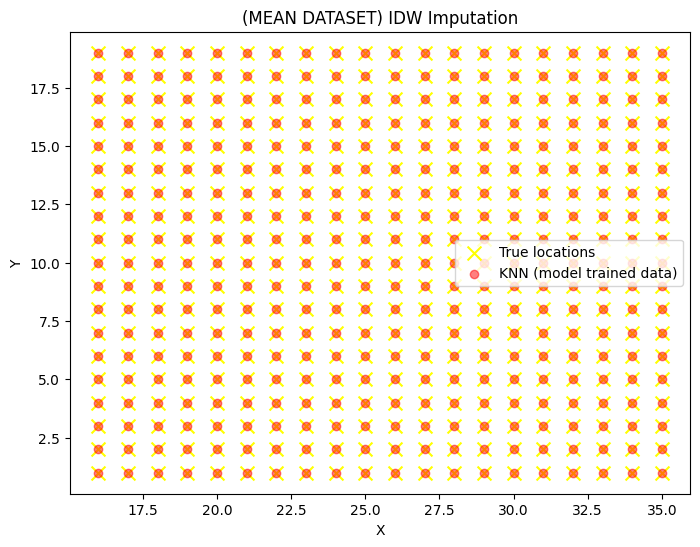

Best parameters: {'n_neighbors': 5}
Best score: -3.758143620771767
Localization Error: 0.0


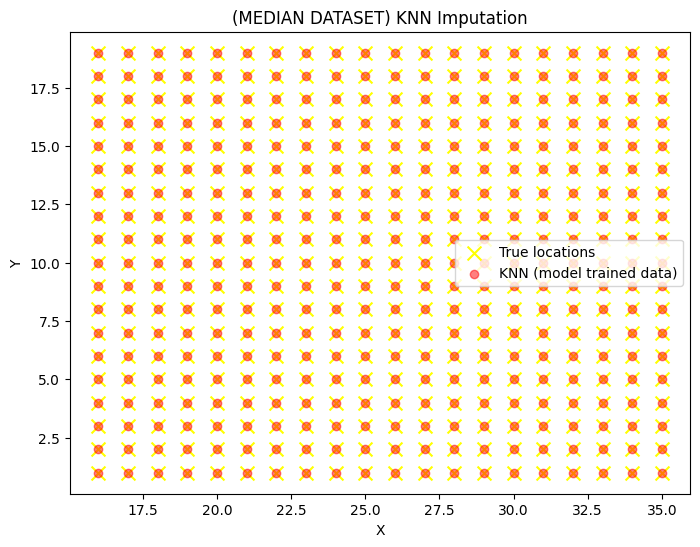

Best parameters: {'n_neighbors': 4}
Best score: -3.7493443919509972
Localization Error: 0.0


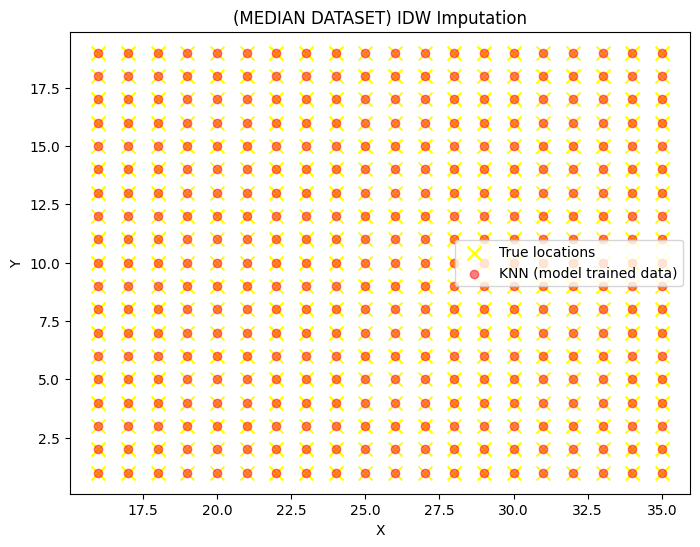

In [14]:
evaluate_knn(ap_mean_by_xy_KNN, ap_mean_by_xy_KNN, plot_label="(MEAN DATASET) KNN Imputation")
evaluate_knn(ap_mean_by_xy_IDW, ap_mean_by_xy_IDW, plot_label="(MEAN DATASET) IDW Imputation")
evaluate_knn(ap_median_by_xy_KNN, ap_median_by_xy_KNN, plot_label="(MEDIAN DATASET) KNN Imputation")
evaluate_knn(ap_median_by_xy_IDW, ap_median_by_xy_IDW, plot_label="(MEDIAN DATASET) IDW Imputation")

### Every 2nd

In [15]:
class SPLITTED_DATASET:
    def __init__(self, mean_knn_split, median_knn_split, mean_IDW_split, median_IDW_split):
        self.mean_knn_split = mean_knn_split
        self.median_knn_split = median_knn_split
        self.mean_IDW_split = mean_IDW_split
        self.median_IDW_split = median_IDW_split

In [16]:
def evaluate_knn_prediction(choose_n):
    CHOOSE_N = choose_n

    training_df_mean_KNN, test_df_mean_KNN = subsample_every_n(ap_mean_by_xy_KNN, CHOOSE_N, (0,0))
    training_df_median_KNN, test_df_median_KNN = subsample_every_n(ap_mean_by_xy_KNN, CHOOSE_N, (0,0))
    training_df_mean_IDW, test_df_mean_IDW = subsample_every_n(ap_mean_by_xy_IDW, CHOOSE_N, (0,0))
    training_df_median_IDW, test_df_median_IDW = subsample_every_n(ap_median_by_xy_IDW, CHOOSE_N, (0,0))

    print(f"Fraction (original mean): {fraction(training_df_mean_KNN, ap_mean_by_xy_KNN)}")
    print(f"Fraction (original median): {fraction(training_df_median_KNN, ap_median_by_xy_KNN)}")
    print(f"Fraction (imputed mean): {fraction(training_df_mean_IDW, ap_mean_by_xy_IDW)}")
    print(f"Fraction (imputed median: {fraction(training_df_median_IDW, ap_median_by_xy_IDW)}")

    plot_RF(training_df_mean_KNN, "Every 3rd (9% of the dataset)")

    evaluate_knn(training_df_mean_KNN, test_df_mean_KNN, plot_label="(MEAN DATASET) KNN Imputation")
    evaluate_knn(training_df_mean_IDW, test_df_mean_IDW, plot_label="(MEAN DATASET) IDW Imputation")
    evaluate_knn(training_df_median_KNN, test_df_median_KNN, plot_label="(MEDIAN DATASET) KNN Imputation")
    evaluate_knn(training_df_median_IDW, test_df_median_IDW, plot_label="(MEDIAN DATASET) IDW Imputation")

    return SPLITTED_DATASET(
        mean_knn_split=(training_df_mean_KNN, test_df_mean_KNN),
        median_knn_split=(training_df_median_KNN, test_df_median_KNN),
        mean_IDW_split=(training_df_mean_IDW, test_df_mean_IDW),
        median_IDW_split=(training_df_median_IDW, test_df_median_IDW)
    )

Fraction (original mean): 23.684210526315788
Fraction (original median): 23.684210526315788
Fraction (imputed mean): 23.684210526315788
Fraction (imputed median: 23.684210526315788


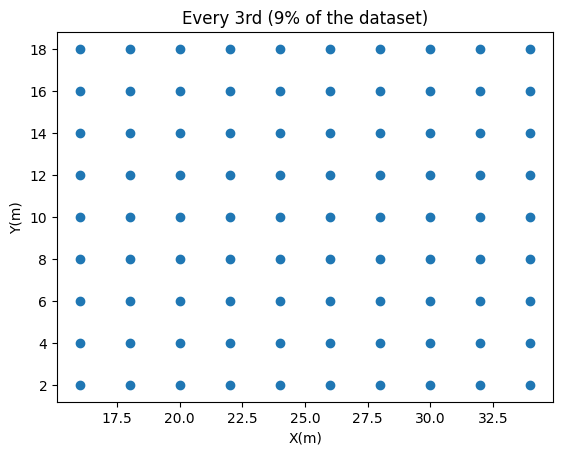

Best parameters: {'n_neighbors': 3}
Best score: -4.245570606853486
Localization Error: 2.5801865079774156


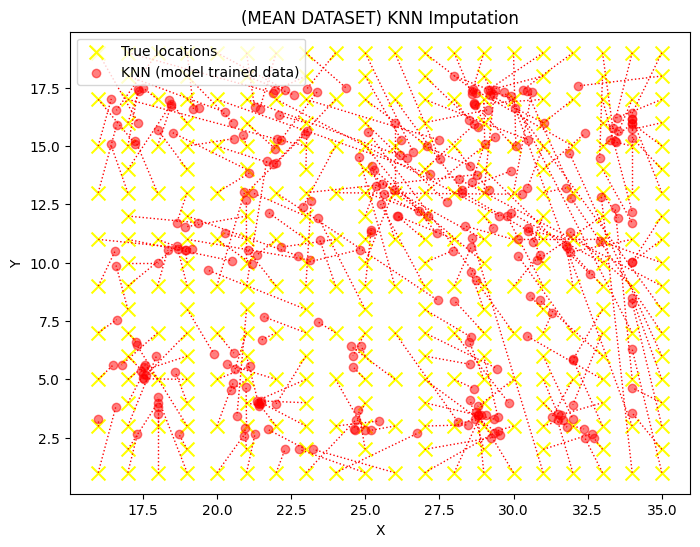

Best parameters: {'n_neighbors': 3}
Best score: -4.09146614606695
Localization Error: 2.4119599216991574


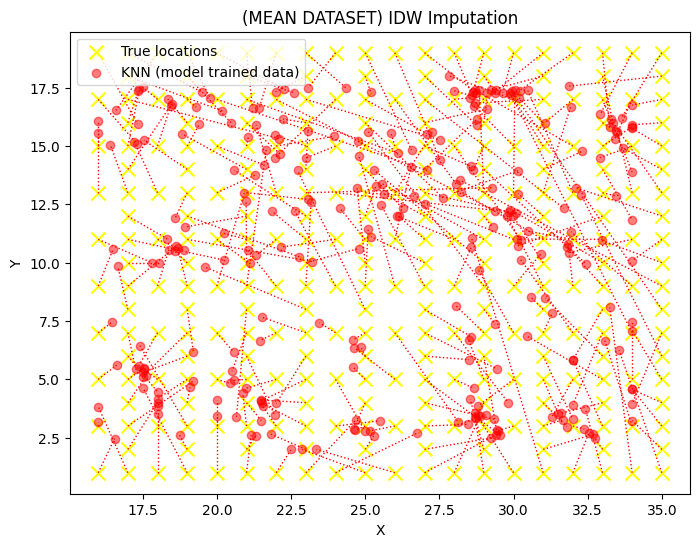

Best parameters: {'n_neighbors': 3}
Best score: -4.245570606853486
Localization Error: 2.5801865079774156


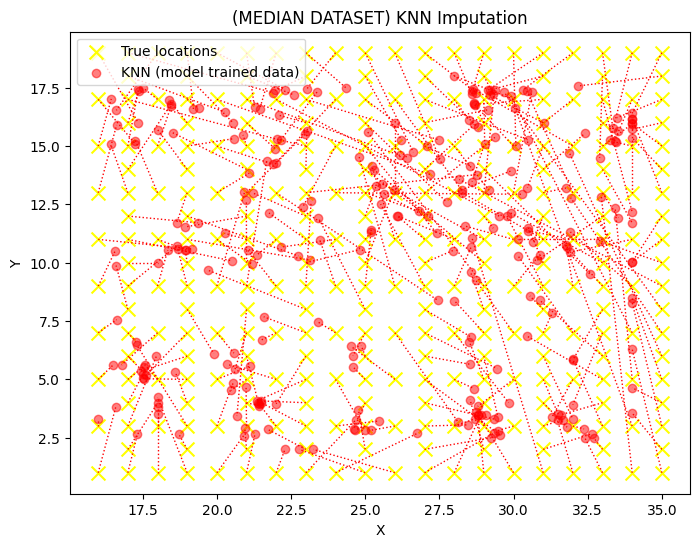

Best parameters: {'n_neighbors': 3}
Best score: -4.052630230103023
Localization Error: 3.013780750868845


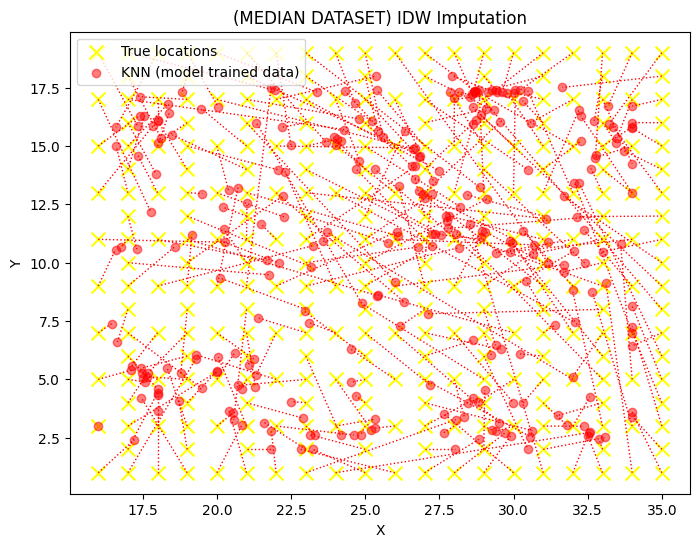

In [17]:
split_every_2nd = evaluate_knn_prediction(2)

### Every 3rd

Fraction (original mean): 9.473684210526317
Fraction (original median): 9.473684210526317
Fraction (imputed mean): 9.473684210526317
Fraction (imputed median: 9.473684210526317


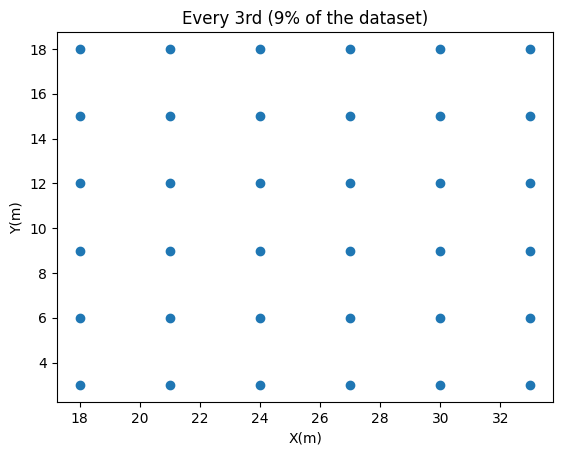

Best parameters: {'n_neighbors': 3}
Best score: -3.8158507757246767
Localization Error: 3.3136101063055587


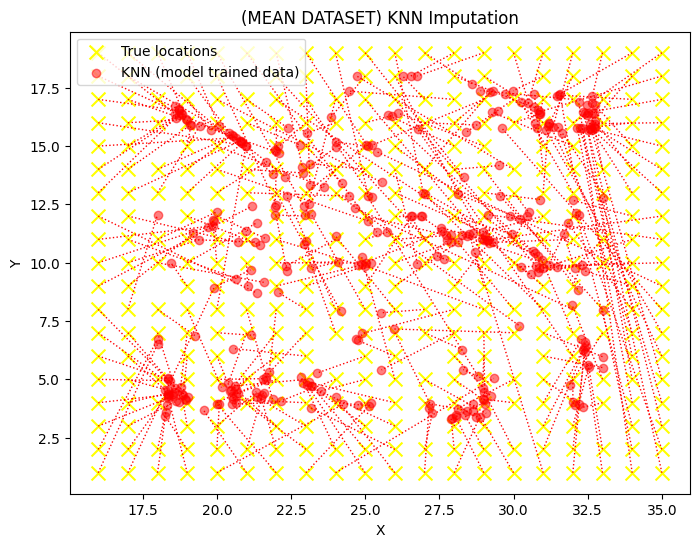

Best parameters: {'n_neighbors': 3}
Best score: -3.751917733499603
Localization Error: 3.269735612023027


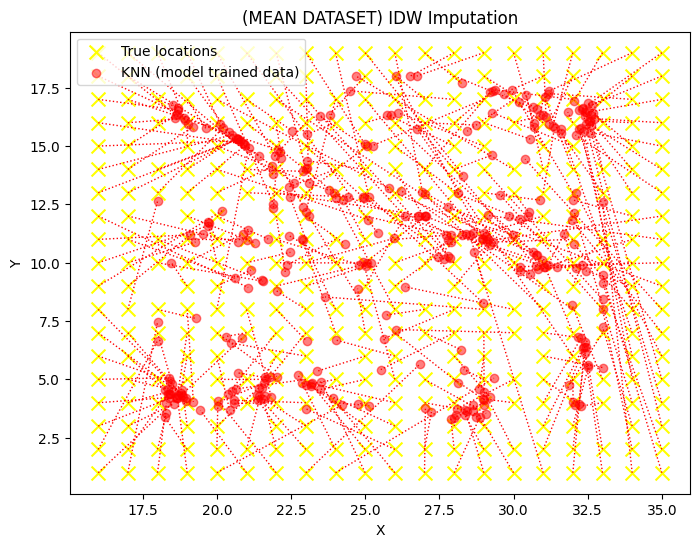

Best parameters: {'n_neighbors': 3}
Best score: -3.8158507757246767
Localization Error: 3.3136101063055587


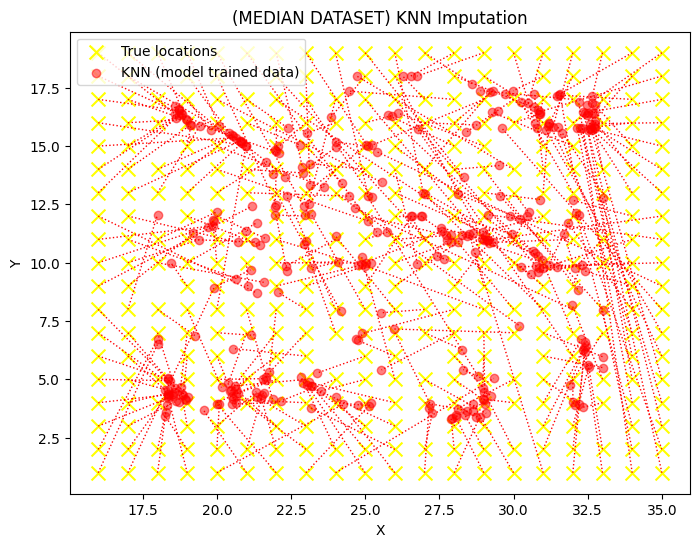

Best parameters: {'n_neighbors': 3}
Best score: -3.7898643804357603
Localization Error: 3.630416737370469


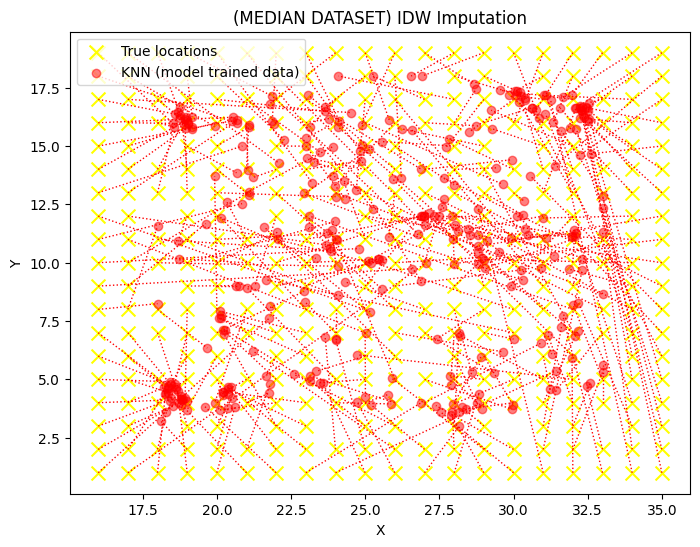

In [18]:
split_every_3rd = evaluate_knn_prediction(3)

### Every 4th

Fraction (original mean): 5.263157894736842
Fraction (original median): 5.263157894736842
Fraction (imputed mean): 5.263157894736842
Fraction (imputed median: 5.263157894736842


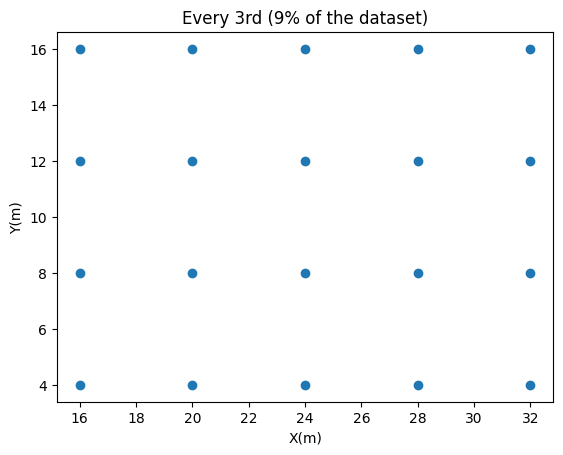

Best parameters: {'n_neighbors': 3}
Best score: -4.330689500243259
Localization Error: 3.740915849329978


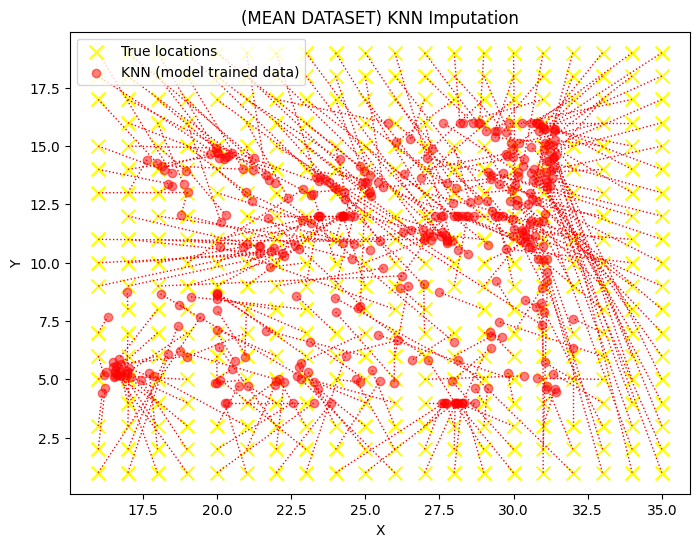

Best parameters: {'n_neighbors': 3}
Best score: -3.902590138994405
Localization Error: 3.68155554183252


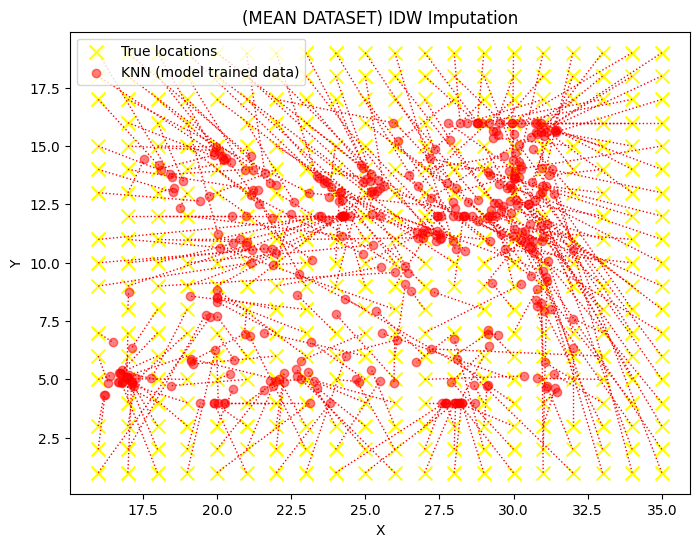

Best parameters: {'n_neighbors': 3}
Best score: -4.330689500243259
Localization Error: 3.740915849329978


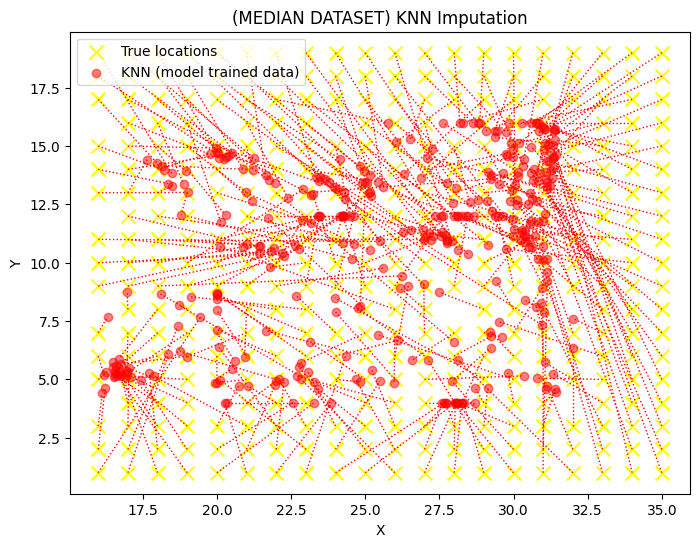

Best parameters: {'n_neighbors': 5}
Best score: -4.328919478490903
Localization Error: 4.285314412693964


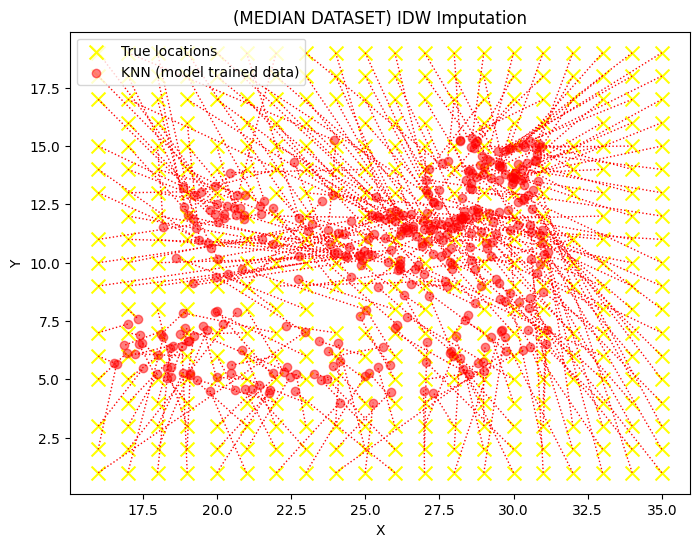

In [19]:
split_every_4th = evaluate_knn_prediction(4)

### Every 5th

Fraction (original mean): 3.1578947368421053
Fraction (original median): 3.1578947368421053
Fraction (imputed mean): 3.1578947368421053
Fraction (imputed median: 3.1578947368421053


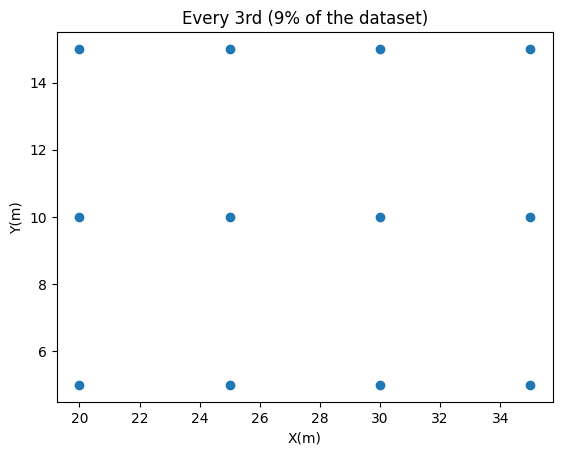

Best parameters: {'n_neighbors': 3}
Best score: -4.272462513809537
Localization Error: 5.2390060164582595


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.27246251 -4.59923246 -4.7065658  -4.64340357 -4.71640551 -4.79691668
         nan]
  warnings.warn(


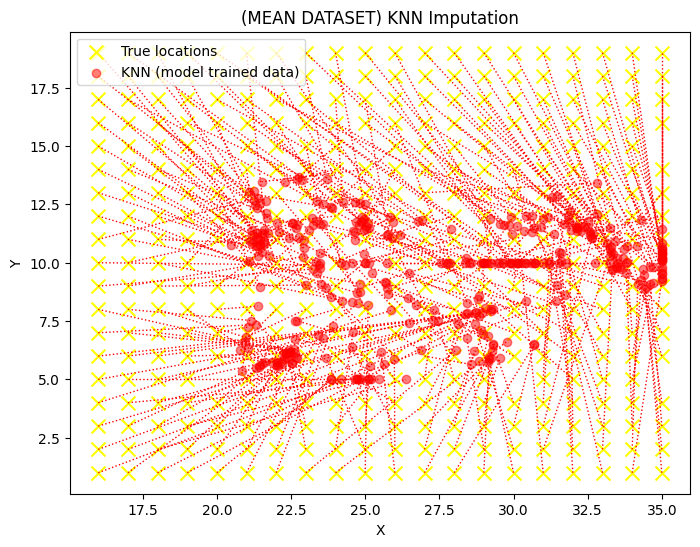

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.04360333 -4.42877964 -4.42802016 -4.54669851 -4.57795113 -4.69505106
         nan]
  warnings.warn(


Best parameters: {'n_neighbors': 3}
Best score: -4.043603333960093
Localization Error: 5.00657361801822


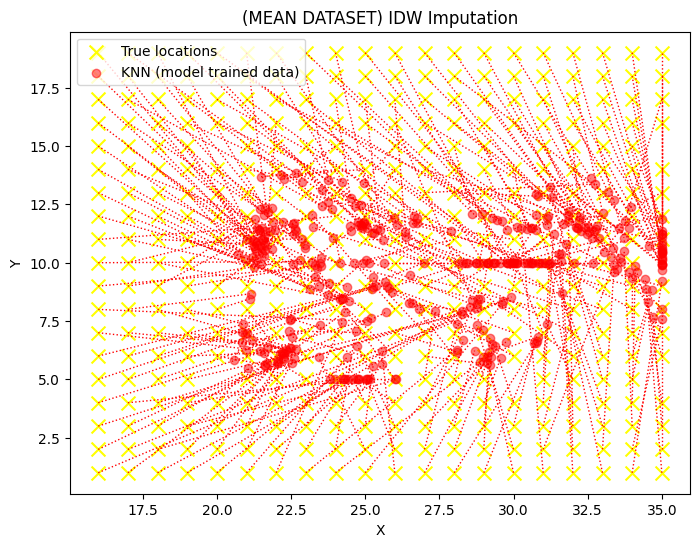

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.27246251 -4.59923246 -4.7065658  -4.64340357 -4.71640551 -4.79691668
         nan]
  warnings.warn(


Best parameters: {'n_neighbors': 3}
Best score: -4.272462513809537
Localization Error: 5.2390060164582595


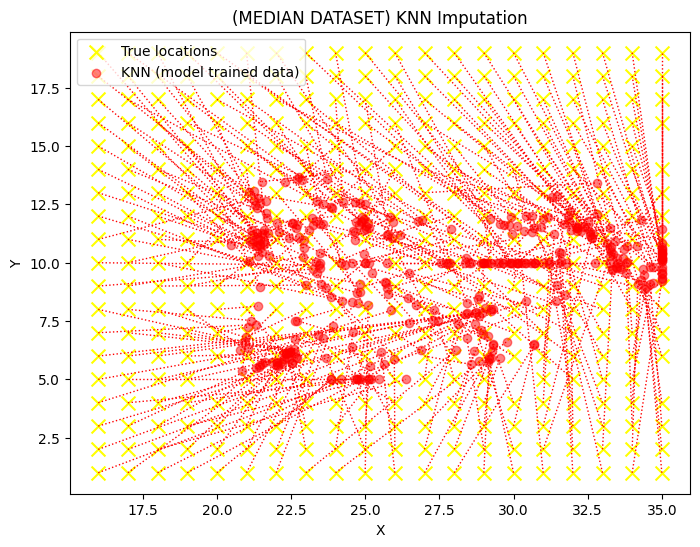

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-4.58809836 -4.65155146 -4.70099863 -4.75085276 -4.7963108  -4.88271571
         nan]
  warnings.warn(


Best parameters: {'n_neighbors': 3}
Best score: -4.588098360756553
Localization Error: 5.375975469365592


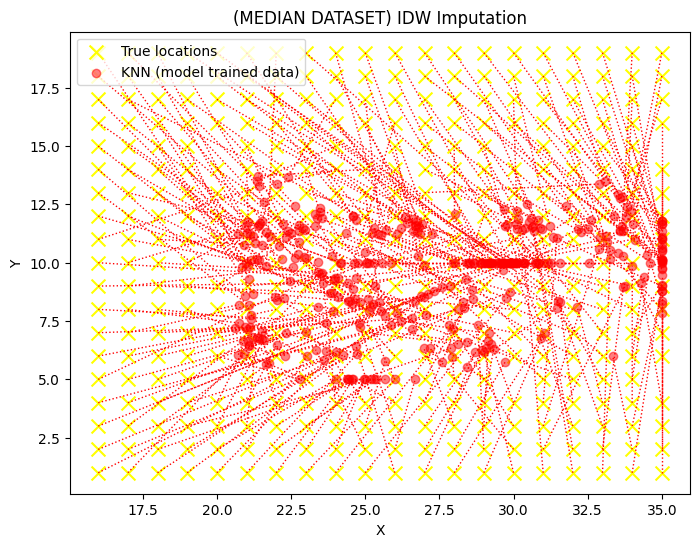

In [20]:
split_every_5th = evaluate_knn_prediction(5)

---

# Table Diffusion Model

In [21]:
def get_beta(t: int, T: int) -> float:
    return (1.0 - math.cos(math.pi * t / T)) / 2.0

def timestep_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=timesteps.device) / max(half - 1, 1))
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = nn.functional.pad(emb, (0, 1))
    return emb

# Tabular U-Net-like MLP backbone
class TabularUNet(nn.Module):
    def __init__(self, input_dim: int, cond_dim: int, time_emb_dim: int, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        # Heads for time and condition
        self.t_proj = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, hidden[0])
        )
        self.c_proj = nn.Sequential(
            nn.Linear(cond_dim, hidden[0]),
            nn.SiLU()
        )

        # Encoder blocks
        enc_dims = [input_dim + hidden[0]*2] + hidden[:-1]
        self.encoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i, o), nn.SiLU())
            for i, o in zip(enc_dims, hidden))

        # Decoder blocks
        dec_dims = hidden[::-1]
        self.decoder = nn.ModuleList(
            nn.Sequential(nn.Linear(i*2, o), nn.SiLU())
            for i, o in zip(dec_dims[:-1], dec_dims[1:]))

        # Final layer
        self.out = nn.Linear(hidden[0], input_dim)

    def forward(self, x: torch.Tensor, cond: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        # x: [batch, input_dim]
        # cond: [batch, cond_dim]
        # t_emb: [batch, time_emb_dim]
        t_h = self.t_proj(t_emb)
        c_h = self.c_proj(cond)

        h = torch.cat([x, c_h, t_h], dim=1)
        skips = []
        # Encode
        for enc in self.encoder:
            h = enc(h)
            skips.append(h)
        # Decode
        for dec in self.decoder:
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = dec(h)
        return self.out(h)

# Diffusion model with Tabular U-Net backbone
class TableDiffusion(nn.Module):
    def __init__(self, rss_dim: int, cond_dim: int = 2, time_emb_dim: int = 128, hidden: list[int] = [512, 256, 128]):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.unet = TabularUNet(
            rss_dim,
            cond_dim,
            time_emb_dim,
            hidden
        )

    def forward(self, noised_rss: torch.Tensor, cond: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = timestep_embedding(t, self.time_emb_dim)
        return self.unet(noised_rss, cond, t_emb)


# Training loop (noise-prediction objective)
def train_table_diffusion(
    model: TableDiffusion,
    X_cond: torch.Tensor,
    Y_rss: torch.Tensor,
    steps: int = 100,
    batch_size: int = 64,
    epochs: int = 100,
    lr: float = 6e-4,
):
    device = (
        torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.to(device)
    ds = torch.utils.data.TensorDataset(X_cond, Y_rss)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    model.train()

    for ep in range(1, epochs+1):
        total = 0.0
        model.train()
        for cond_b, rss_b in dl:
            cond_b, rss_b = cond_b.to(device), rss_b.to(device)
            loss_acc = 0.0
            for t in range(steps):
                beta = get_beta(t, steps)
                noise = torch.randn_like(rss_b) * math.sqrt(beta)
                x_t = rss_b + noise
                t_vec = torch.full((rss_b.size(0),), t, dtype=torch.long, device=device)
                pred = model(x_t, cond_b, t_vec)
                loss_acc += mse(pred, noise)
            loss = loss_acc / steps
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()
        if ep % 10 == 0 or ep == 1:
            print(f"[TableDiffusion] Epoch {ep}/{epochs} - loss: {total/len(dl):.4f}")
    return model

# Reverse sampling (denoise from Gaussian)
def sample_table_diffusion(
        model: TableDiffusion,
        X_cond: torch.Tensor,
        diffusion_steps: int = 100
) -> np.ndarray:
    device = (
    torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print("Device:", device)
    model.eval()
    X_cond = X_cond.to(device)
    print(X_cond.shape)
    n, _ = X_cond.shape
    rss_dim = model.unet.out.out_features
    samples = torch.randn(n, rss_dim, device=device)

    with torch.no_grad():
        for t in reversed(range(diffusion_steps)):
            beta = get_beta(t, diffusion_steps)
            t_vec = torch.full((n,), t, dtype=torch.long, device=device)
            pred_eps = model(samples, X_cond, t_vec)
            samples = samples - pred_eps * math.sqrt(beta)
        return samples.cpu().numpy()

# Validation noise-prediction loss (quick proxy)
def eval_noise_mse(model, Xc, Yr, steps=50):
    device = next(model.parameters()).device
    mse = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        Xc, Yr = Xc.to(device), Yr.to(device)
        tot = 0.0
        for t in range(steps):
            beta = get_beta(t, steps)
            eps = torch.randn_like(Yr) * math.sqrt(beta)
            x_t = Yr + eps
            t_vec = torch.full((Yr.size(0),), t, dtype=torch.long, device=device)
            pred = model(x_t, Xc, t_vec)
            tot += mse(pred, eps).item()
        return tot / steps

In [22]:
def train_tdm(dataset, ap_cols, cond_cols, steps=75, batch_size=64, epochs=200, lr=6.3e-4):
    # Replace missing APs with a sentinel before scaling
    td_train_filled = dataset.copy()
    td_train_filled[ap_cols] = td_train_filled[ap_cols].fillna(-110)

    # Train/val/test split
    X_cond = td_train_filled[cond_cols].values.astype("float32")
    Y_rss = td_train_filled[ap_cols].values.astype("float32")

    # Scale RSS targets only
    rss_scaler = StandardScaler()
    Y_rss_s = rss_scaler.fit_transform(Y_rss)

    print(f"Y_rss.shape: {Y_rss_s.shape}")

    # Tensors for X
    X_cond_t  = torch.tensor(X_cond,   dtype=torch.float32)
    # Tensors for Y
    Y_rss_t  = torch.tensor(Y_rss_s, dtype=torch.float32)

    # Instantiate, train, and demonstrate generation at custom coordinates
    rss_dim = len(ap_cols)
    td_model = TableDiffusion(rss_dim=rss_dim, cond_dim=2, time_emb_dim=128)

    td_model = train_table_diffusion(
        td_model,
        X_cond_t,
        Y_rss_t,
        steps=steps,          # can tune (e.g., 50–200)
        batch_size=batch_size,
        epochs=epochs,        # can tune
        lr=lr
    )

    val_noise_mse = eval_noise_mse(td_model, X_cond_t, Y_rss_t, steps=50)
    print(f"[TableDiffusion] Validation noise-prediction MSE: {val_noise_mse:.4f}")

    return td_model, rss_scaler, X_cond_t, Y_rss_t


In [23]:
def generate_rss_values(model, coords_dataset, rss_scaler, ap_cols, diffusion_steps=100):
    """
    Generate synthetic RSS values for the given condition columns.
    """

    gen_rss_values = sample_table_diffusion(model, coords_dataset, diffusion_steps)

    # Inverse transform to get the RSS values in the original scale
    synthetic_rss = rss_scaler.inverse_transform(gen_rss_values)

    synthetic_rss_df = pd.DataFrame(synthetic_rss, columns=ap_cols)
    return synthetic_rss_df

def generate_synthetic_rss(td_model, scaler, coordinates, ap_cols, diffusion_steps=100):
    coords_t = torch.tensor(coordinates.values,  dtype=torch.float32)
    synthetic_rss  = generate_rss_values(td_model, coords_t, scaler, ap_cols, diffusion_steps=diffusion_steps)

    synthetic_dataset = pd.concat([synthetic_rss, coordinates], axis=1)
    return synthetic_dataset

---

In [24]:
def evaluate_tdm_prediction(train_dataset, test_dataset, epochs=250, batch_size=64, diffusion_steps=100):
    training_df = train_dataset.copy()
    test_df = test_dataset.copy()

    tdm_model, scaler_tdm, _, _ = train_tdm(
            training_df,
            ap_cols=get_ap_columns(training_df),
            cond_cols=['X','Y'],
            epochs=epochs,
            batch_size=batch_size
    )

    synthetic_df = generate_synthetic_rss(
        td_model=tdm_model,
        scaler=scaler_tdm,
        coordinates=test_df[['X','Y']],
        ap_cols=get_ap_columns(test_df),
        diffusion_steps=diffusion_steps
    )

    X_ap_train = training_df[get_ap_columns(training_df)].values
    y_xy_train = training_df[['X','Y']].values

    X_ap_test = test_df[get_ap_columns(test_df)].values
    y_xy_test = test_df[['X','Y']].values

    X_ap_synth = synthetic_df[get_ap_columns(synthetic_df)].values
    y_xy_synth = synthetic_df[['X','Y']].values

    X_combined = pd.concat([pd.DataFrame(X_ap_train), pd.DataFrame(X_ap_synth)], axis=0).values
    y_combined = pd.concat([pd.DataFrame(y_xy_train), pd.DataFrame(y_xy_synth)], axis=0).values

    knn_evaluation(X_combined, X_ap_test, y_combined, y_xy_test)

Y_rss.shape: (90, 18)
Device: mps
[TableDiffusion] Epoch 1/1000 - loss: 0.5274
[TableDiffusion] Epoch 10/1000 - loss: 0.4961
[TableDiffusion] Epoch 20/1000 - loss: 0.4792
[TableDiffusion] Epoch 30/1000 - loss: 0.4582
[TableDiffusion] Epoch 40/1000 - loss: 0.4237
[TableDiffusion] Epoch 50/1000 - loss: 0.4510
[TableDiffusion] Epoch 60/1000 - loss: 0.4144
[TableDiffusion] Epoch 70/1000 - loss: 0.5364
[TableDiffusion] Epoch 80/1000 - loss: 0.3468
[TableDiffusion] Epoch 90/1000 - loss: 0.2816
[TableDiffusion] Epoch 100/1000 - loss: 0.2707
[TableDiffusion] Epoch 110/1000 - loss: 0.2361
[TableDiffusion] Epoch 120/1000 - loss: 0.1874
[TableDiffusion] Epoch 130/1000 - loss: 0.1609
[TableDiffusion] Epoch 140/1000 - loss: 0.1622
[TableDiffusion] Epoch 150/1000 - loss: 0.1504
[TableDiffusion] Epoch 160/1000 - loss: 0.1420
[TableDiffusion] Epoch 170/1000 - loss: 0.1375
[TableDiffusion] Epoch 180/1000 - loss: 0.1367
[TableDiffusion] Epoch 190/1000 - loss: 0.1382
[TableDiffusion] Epoch 200/1000 - los

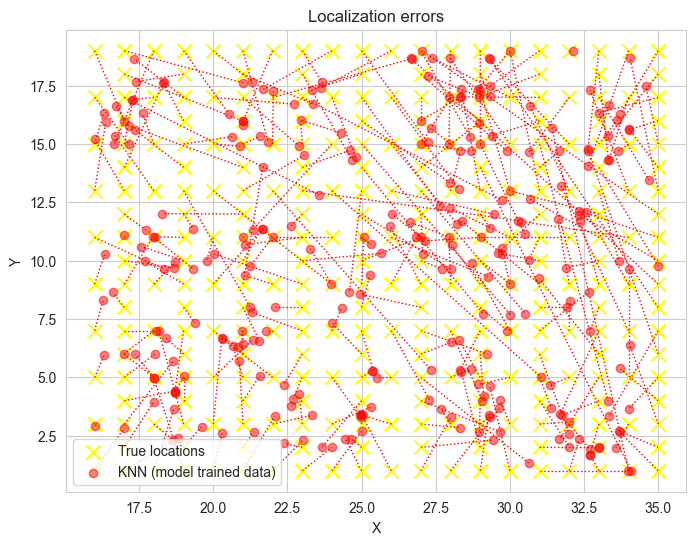

In [ ]:
evaluate_tdm_prediction(
    split_every_2nd.mean_knn_split[0],
    split_every_2nd.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.mean_knn_split[0],
    split_every_3rd.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.mean_knn_split[0],
    split_every_4th.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.mean_knn_split[0],
    split_every_5th.mean_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)


In [ ]:
evaluate_tdm_prediction(
    split_every_2nd.median_knn_split[0],
    split_every_2nd.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.median_knn_split[0],
    split_every_3rd.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.median_knn_split[0],
    split_every_4th.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.median_knn_split[0],
    split_every_5th.median_knn_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)


In [ ]:
evaluate_tdm_prediction(
    split_every_2nd.mean_IDW_split[0],
    split_every_2nd.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.mean_IDW_split[0],
    split_every_3rd.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.mean_IDW_split[0],
    split_every_4th.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.mean_IDW_split[0],
    split_every_5th.mean_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)


In [ ]:
evaluate_tdm_prediction(
    split_every_2nd.median_IDW_split[0],
    split_every_2nd.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_3rd.median_IDW_split[0],
    split_every_3rd.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_4th.median_IDW_split[0],
    split_every_4th.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)

evaluate_tdm_prediction(
    split_every_5th.median_IDW_split[0],
    split_every_5th.median_IDW_split[1],
    epochs=4000,
    batch_size=64,
    diffusion_steps=200
)
